In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.colors as mcolors
plt.rcParams.update({'font.size': 15})
import numpy as np
import os

from itertools import product, combinations
from scipy.stats import pearsonr

In [2]:
datasets = [ "pile", "refinedweb",  "dolma3", "dolmino", "sft",  "dpo"] #
run_model = "olmo3"

# Define custom colors for datasets
colors = {
    "dolma3": mcolors.to_rgba("#1f77b4", alpha=0.7),   # blue, lighter
    "dolmino": mcolors.to_rgba("#1f77b4", alpha=1.0), # blue, darker
    "dpo": "#2ca02c",   # green
    "DPO": "#2ca02c",   # green
    "sft": "#ff7f0e",  # orange
    "SFT": "#ff7f0e",   
    "refinedweb": "#4B0082",  # purple
    "pile": "#e377c2", 
}

# order = [
#         'expanded social welfare state','open foreign policy', 
#         'expanded environmental protection', 'liberal society', 
#         'law and order', 'liberal economic policy', 
#         'restrictive financial policy', 'restrictive migration policy'
#     ]
order = ['expanded_social_welfare_state', 'open_foreign_policy','expanded_environ_protection',
         'liberal_society', 'law_and_order',
        'liberal_economic_policy', 'restrictive_financial_policy', 'restrictive_migration_policy']

In [3]:
all_results = {}
for policy in order:
    all_results[policy] = []
# Load and compute results for each dataset
for dataset in datasets:
    df = pd.read_csv(f"out_models_2026/{dataset}_left_right.csv")
    for policy in order:
        tmp_dic = df[policy+ "_stance"].value_counts().to_dict()
        support = tmp_dic.get("support", 0)
        oppose = tmp_dic.get("oppose", 0)
        # neutral = tmp_dic.get("neutral", 0)
        # all_results[policy].append((support - oppose) / max(support + oppose, 1))
        for stance in [support, oppose]:
            all_results[policy].append(stance)
    print(f"Processed dataset: {dataset}, total samples: {len(df)}")
# Convert to DataFrame for plotting
results_df = pd.DataFrame(all_results).T
# results_df.columns = [dataset.capitalize().replace("_", "-") for dataset in datasets]
results_df.index = [policy.replace("expanded ", "") for policy in results_df.index]

n_cats = 2  # support, oppose

# 1) Build the full list of column labels (optional, but nice to have)
col_names = []
for dataset in datasets:
    col_names.extend([f"{dataset}_support", f"{dataset}_oppose"])
results_df.columns = col_names  # must match the actual number of columns

# 2) Build level arrays: one list for 'Dataset', one for 'Stance'
level_dataset = []
level_stance = []
for dataset in datasets:
    level_dataset.extend([dataset.capitalize()] * n_cats)
    level_stance.extend(["sup", "opp"])

# 3) Create MultiIndex and assign
multi_index = pd.MultiIndex.from_arrays(
    [level_dataset, level_stance],
    names=["Dataset", "Stance"]
)
results_df.columns = multi_index

# 4) Export LaTeX (multirow/multicolumn headers)
latex_str = results_df.to_latex(float_format="%.2f", multicolumn=True, multirow=True).replace("_", " ")
print(latex_str)


Processed dataset: pile, total samples: 10370
Processed dataset: refinedweb, total samples: 8688
Processed dataset: dolma3, total samples: 28456
Processed dataset: dolmino, total samples: 9230
Processed dataset: sft, total samples: 3812
Processed dataset: dpo, total samples: 5146
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
Dataset & \multicolumn{2}{r}{Pile} & \multicolumn{2}{r}{Refinedweb} & \multicolumn{2}{r}{Dolma3} & \multicolumn{2}{r}{Dolmino} & \multicolumn{2}{r}{Sft} & \multicolumn{2}{r}{Dpo} \\
Stance & sup & opp & sup & opp & sup & opp & sup & opp & sup & opp & sup & opp \\
\midrule
expanded social welfare state & 916 & 428 & 657 & 310 & 1497 & 509 & 525 & 220 & 222 & 13 & 304 & 66 \\
open foreign policy & 733 & 534 & 473 & 306 & 1765 & 628 & 600 & 194 & 163 & 27 & 132 & 39 \\
expanded environ protection & 1019 & 305 & 837 & 217 & 4773 & 766 & 1394 & 258 & 387 & 11 & 558 & 80 \\
liberal society & 2618 & 852 & 2036 & 640 & 6269 & 1720 & 2043 & 558 & 1817 & 119 & 2188 & 229 \\
law an

In [4]:
all_results = {}
for policy in order:
    all_results[policy] = []

# Load and compute results for each dataset
for dataset in datasets:
    df = pd.read_csv(f"out_models_2026/{dataset}_left_right.csv")
    for policy in order:
        tmp_dic = df[policy+"_stance"].value_counts().to_dict()
        support = tmp_dic.get("support", 0)
        oppose = tmp_dic.get("oppose", 0)
        neutral = tmp_dic.get("neutral", 0)
        print(dataset, policy, "Support: ", support, "Oppose: ", oppose, "Neutral: ", neutral)
        # all_results[policy].append((support - oppose) / max(support + oppose, 1))
        all_results[policy].append((support + oppose) / max(support + oppose + neutral, 1))
        print(all_results[policy][-1])

# Convert to DataFrame for plotting
results_df = pd.DataFrame(all_results).T
results_df.columns = [dataset.capitalize().replace("_", "-") for dataset in datasets]
results_df.index = [policy.replace("expanded ", "") for policy in results_df.index]
display(results_df)

pile expanded_social_welfare_state Support:  916 Oppose:  428 Neutral:  9026
0.12960462873674058
pile open_foreign_policy Support:  733 Oppose:  534 Neutral:  9103
0.12217936354869817
pile expanded_environ_protection Support:  1019 Oppose:  305 Neutral:  9046
0.12767598842815814
pile liberal_society Support:  2618 Oppose:  852 Neutral:  6900
0.33461909353905495
pile law_and_order Support:  1098 Oppose:  1515 Neutral:  7757
0.251976856316297
pile liberal_economic_policy Support:  590 Oppose:  1598 Neutral:  8182
0.21099324975891995
pile restrictive_financial_policy Support:  362 Oppose:  981 Neutral:  9027
0.12950819672131147
pile restrictive_migration_policy Support:  432 Oppose:  502 Neutral:  9436
0.09006750241080039
refinedweb expanded_social_welfare_state Support:  657 Oppose:  310 Neutral:  7721
0.11130294659300184
refinedweb open_foreign_policy Support:  473 Oppose:  306 Neutral:  7909
0.08966390423572744
refinedweb expanded_environ_protection Support:  837 Oppose:  217 Neutral: 

,Pile,Refinedweb,Dolma3,Dolmino,Sft,Dpo
expanded_social_welfare_state,0.129605,0.111303,0.070495,0.080715,0.061712,0.071901
open_foreign_policy,0.122179,0.089664,0.084095,0.086024,0.049843,0.033236
expanded_environ_protection,0.127676,0.121317,0.194651,0.178982,0.104462,0.124004
liberal_society,0.334619,0.308011,0.280749,0.281829,0.508537,0.469776
law_and_order,0.251977,0.186349,0.172793,0.162423,0.088212,0.098717
liberal_economic_policy,0.210993,0.178062,0.170403,0.180607,0.056430,0.048776
restrictive_financial_policy,0.129508,0.112109,0.074571,0.083640,0.013393,0.030315
restrictive_migration_policy,0.090068,0.058587,0.036477,0.037382,0.047256,0.049563


# 95% Confidence Intervals

In [5]:
all_results = {}
ci_low = {}
ci_high = {}

z = 1.96  # for ~95% CI

for policy in order:
    all_results[policy] = []
    ci_low[policy] = []
    ci_high[policy] = []

for dataset in datasets:
    df = pd.read_csv(f"out_models_2026/{dataset}_left_right.csv")
    for policy in order:
        tmp_dic = df[policy+"_stance"].value_counts().to_dict()
        support = tmp_dic.get("support", 0)
        oppose = tmp_dic.get("oppose", 0)
        neutral = tmp_dic.get("neutral", 0)

        n = support + oppose
        if n == 0:
            mean_val = 0.0
            low_val = 0.0
            high_val = 0.0
        else:
            # proportion of support among (support + oppose)
            p = support / n
            se = np.sqrt(p * (1 - p) / n)
            p_low = p - z * se
            p_high = p + z * se

            # transform to your metric: m = (support - oppose)/(support + oppose) = 2p - 1
            mean_val = 2 * p - 1
            low_val = 2 * p_low - 1
            high_val = 2 * p_high - 1

        all_results[policy].append(mean_val)
        ci_low[policy].append(low_val)
        ci_high[policy].append(high_val)

In [6]:
# Convert to DataFrame for plotting
results_df = pd.DataFrame(all_results).T

datasets_name = ["SFT-mix" if d == "tulu_sft" else d for d in datasets]

legend_label_overrides = {
    "dpo": "DPO3",
    "sft": "SFT3",
    "dolmino": "Dolmino3",
}
results_df.columns = [
    legend_label_overrides.get(dataset, dataset.capitalize().replace("_", "-"))
    for dataset in datasets_name
]

# CI bounds aligned with results_df
ci_low_df = pd.DataFrame(ci_low).T
ci_high_df = pd.DataFrame(ci_high).T
ci_low_df.columns = results_df.columns
ci_high_df.columns = results_df.columns

# symmetric half-width for error bars
yerr = (ci_high_df - ci_low_df) / 2.0

print(results_df.to_dict())
document_stances = results_df.to_dict()
results_df.index = [policy.replace("expanded ", "") for policy in results_df.index]
display(results_df)

{'Pile': {'expanded_social_welfare_state': 0.36309523809523814, 'open_foreign_policy': 0.15706393054459356, 'expanded_environ_protection': 0.5392749244712991, 'liberal_society': 0.5089337175792508, 'law_and_order': -0.15958668197474168, 'liberal_economic_policy': -0.4606946983546618, 'restrictive_financial_policy': -0.4609084139985108, 'restrictive_migration_policy': -0.07494646680942185}, 'Refinedweb': {'expanded_social_welfare_state': 0.35884177869700107, 'open_foreign_policy': 0.21437740693196417, 'expanded_environ_protection': 0.588235294117647, 'liberal_society': 0.5216741405082213, 'law_and_order': -0.13279802347127856, 'liberal_economic_policy': -0.48674854557207503, 'restrictive_financial_policy': -0.4106776180698152, 'restrictive_migration_policy': -0.09233791748526521}, 'Dolma3': {'expanded_social_welfare_state': 0.4925224327018942, 'open_foreign_policy': 0.4751358127872962, 'expanded_environ_protection': 0.7234157790214841, 'liberal_society': 0.5694079359118789, 'law_and_ord

,Pile,Refinedweb,Dolma3,Dolmino3,SFT3,DPO3
expanded_social_welfare_state,0.363095,0.358842,0.492522,0.409396,0.889362,0.643243
open_foreign_policy,0.157064,0.214377,0.475136,0.511335,0.715789,0.543860
expanded_environ_protection,0.539275,0.588235,0.723416,0.687651,0.944724,0.749216
liberal_society,0.508934,0.521674,0.569408,0.570934,0.877066,0.810509
law_and_order,-0.159587,-0.132798,-0.100264,-0.160774,-0.077381,-0.299213
liberal_economic_policy,-0.460695,-0.486749,-0.254279,-0.241752,-0.348837,-0.163347
restrictive_financial_policy,-0.460908,-0.410678,-0.502356,-0.458549,-0.529412,-0.474359
restrictive_migration_policy,-0.074946,-0.092338,-0.221580,-0.292754,-0.444444,-0.301961


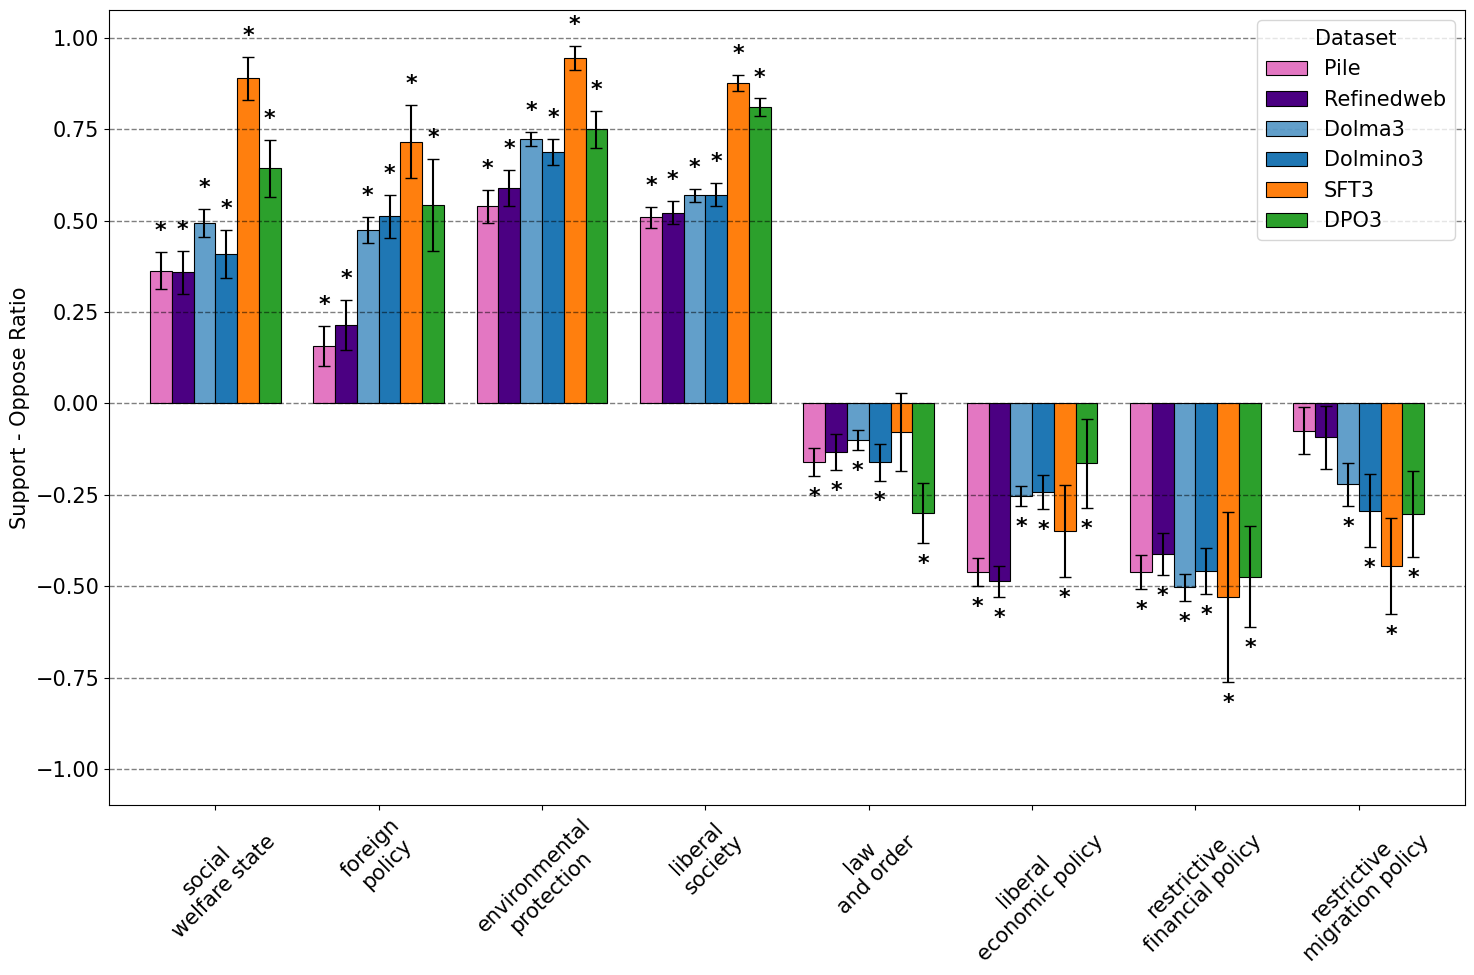

In [7]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import matplotlib.container as mcontainer

# Is each bar's stance significantly different from 0? Equivalent to testing
# whether the support proportion differs from 0.5 (one-sample proportion z-test),
# Holm-corrected across all dataset x policy bars in the figure.
map_names = {'expanded_social_welfare_state':"social_welfare_state", 'open_foreign_policy':"foreign_policy", 'expanded_environ_protection':"environmental_protection",
         'liberal_society': 'liberal_society', 'law_and_order': 'law_and_order',
        'liberal_economic_policy': 'liberal_economic_policy', 'restrictive_financial_policy': 'restrictive_financial_policy', 'restrictive_migration_policy': 'restrictive_migration_policy'}

sig_rows = []
for dataset in datasets:
    df = pd.read_csv(f"out_models_2026/{dataset}_left_right.csv")
    for policy in order:
        tmp_dic = df[policy + "_stance"].value_counts().to_dict()
        support = tmp_dic.get("support", 0)
        oppose = tmp_dic.get("oppose", 0)
        n = support + oppose
        _, pval = proportions_ztest(support, n, value=0.5)
        sig_rows.append({"dataset": dataset, "policy": policy, "p_raw": pval})

sig_df = pd.DataFrame(sig_rows)
_, sig_df["p_holm"], _, _ = multipletests(sig_df["p_raw"], alpha=0.05, method="holm")
sig_df["significant"] = sig_df["p_holm"] < 0.05
sig_lookup = sig_df.set_index(["dataset", "policy"])["significant"].to_dict()

width = 0.8 / len(datasets)  # bar width so all models fit

ax = results_df.plot(
    kind="bar",
    width=0.8,
    figsize=(15, 10),
    color=[colors[dataset] for dataset in datasets_name],
    yerr=yerr.values.T,   # or yerr=yerr.to_numpy().T, shape (n_series, n_categories)
    capsize=4,            # nice little caps on error bars
    # error_kw={"ecolor": "#f5f5f5", "elinewidth": 1.2, "capthick": 1.2},
    linewidth=0.8,
    edgecolor="black",
)

for i in np.arange(-1, 1.01, 0.25):
    ax.axhline(i, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Star bars whose stance is significantly different from 0, placed past the CI cap
bar_containers = [c for c in ax.containers if isinstance(c, mcontainer.BarContainer)]
err_vals = yerr.values.T  # (n_datasets, n_policies), aligned to bar_containers/datasets order
for container, dataset, errs in zip(bar_containers, datasets, err_vals):
    for bar, policy, err in zip(container, results_df.index, errs):
        if sig_lookup.get((dataset, policy), False):
            height = bar.get_height()
            offset = 0.03
            y = height + err + offset if height >= 0 else height - err - offset
            va = "bottom" if height >= 0 else "top"
            ax.text(bar.get_x() + bar.get_width() / 2, y, "*",
                    ha="center", va=va, fontsize=16, fontweight="bold")

plt.ylabel("Support - Oppose Ratio")
labels = [map_names[l.get_text()].replace("_", " ") for l in ax.get_xticklabels()]
new_labels = [
    lab.replace(" ", "\n", 1) if " " in lab else lab
    for lab in labels
]
ax.set_xticklabels(new_labels, rotation=0)
plt.xticks(rotation=45)
plt.legend(title="Dataset", loc="upper right")
plt.tight_layout()
plt.savefig(f"plots/policy_stance_by_dataset_{run_model}.png", dpi=300)
plt.show()

# Pairwise significance tests (two-proportion z-test, Holm-corrected)

Tests whether the `support / (support + oppose)` proportion differs significantly between two datasets, per policy issue. This formalizes the "strongest stance" / "twice as much" claims made from the bar chart above instead of eyeballing CI overlap.

In [8]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2_contingency

# Recompute raw support/oppose counts per dataset x policy (same source as the CI cell above)
counts = {}
for dataset in datasets:
    df = pd.read_csv(f"out_models_2026/{dataset}_left_right.csv")
    counts[dataset] = {}
    for policy in order:
        tmp_dic = df[policy + "_stance"].value_counts().to_dict()
        counts[dataset][policy] = (tmp_dic.get("support", 0), tmp_dic.get("oppose", 0))

# Omnibus chi-square per policy: are the 6 datasets' stance proportions homogeneous at all?
print("Omnibus chi-square (all datasets) per policy:")
omnibus = {}
for policy in order:
    table = np.array([counts[d][policy] for d in datasets])
    chi2, p, dof, _ = chi2_contingency(table)
    omnibus[policy] = p
    print(f"  {policy}: chi2={chi2:.1f}, dof={dof}, p={p:.2e}")

# Pairwise two-proportion z-tests within each policy, Holm-corrected across all pairs in that policy
rows = []
for policy in order:
    for d1, d2 in combinations(datasets, 2):
        s1, o1 = counts[d1][policy]
        s2, o2 = counts[d2][policy]
        n1, n2 = s1 + o1, s2 + o2
        stance1 = (s1 - o1) / n1
        stance2 = (s2 - o2) / n2
        stat, pval = proportions_ztest(np.array([s1, s2]), np.array([n1, n2]))
        rows.append({
            "policy": policy, "dataset_1": d1, "dataset_2": d2,
            "stance_1": stance1, "stance_2": stance2,
            "n_1": n1, "n_2": n2, "min_n": min(n1, n2),
            "z": stat, "p_raw": pval,
        })

pairwise_df = pd.DataFrame(rows)

# Holm-Bonferroni correction across ALL pairwise tests (all policies x all pairs)
reject, p_holm, _, _ = multipletests(pairwise_df["p_raw"], alpha=0.05, method="holm")
pairwise_df["p_holm"] = p_holm
pairwise_df["significant"] = reject

# Flag comparisons where at least one side has few docs, so a non-significant result
# isn't mistaken for "no difference" when it's really "underpowered"
pairwise_df["low_n"] = pairwise_df["min_n"] < 100

display(pairwise_df.sort_values(["policy", "p_holm"]).round(4))


Omnibus chi-square (all datasets) per policy:
  expanded_social_welfare_state: chi2=103.5, dof=5, p=9.76e-21
  open_foreign_policy: chi2=170.6, dof=5, p=5.43e-35
  expanded_environ_protection: chi2=144.1, dof=5, p=2.42e-29
  liberal_society: chi2=491.1, dof=5, p=6.54e-104
  law_and_order: chi2=23.8, dof=5, p=2.42e-04
  liberal_economic_policy: chi2=138.0, dof=5, p=4.78e-28
  restrictive_financial_policy: chi2=7.7, dof=5, p=1.71e-01
  restrictive_migration_policy: chi2=38.0, dof=5, p=3.79e-07


,policy,dataset_1,dataset_2,stance_1,stance_2,n_1,n_2,min_n,z,p_raw,p_holm,significant,low_n
33,expanded_environ_protection,pile,sft,0.5393,0.9447,1324,398,398,-9.1616,0.0000,0.0,True,False
37,expanded_environ_protection,refinedweb,sft,0.5882,0.9447,1054,398,398,-8.3273,0.0000,0.0,True,False
31,expanded_environ_protection,pile,dolma3,0.5393,0.7234,1324,5539,1324,-8.2933,0.0000,0.0,True,False
42,expanded_environ_protection,dolmino,sft,0.6877,0.9447,1652,398,398,-6.8177,0.0000,0.0,True,False
40,expanded_environ_protection,dolma3,sft,0.7234,0.9447,5539,398,398,-6.3223,0.0000,0.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,restrictive_migration_policy,dolma3,dolmino,-0.2216,-0.2928,1038,345,345,1.1796,0.2382,1.0,False,False
116,restrictive_migration_policy,dolma3,dpo,-0.2216,-0.3020,1038,255,255,1.1839,0.2364,1.0,False,False
117,restrictive_migration_policy,dolmino,sft,-0.2928,-0.4444,345,180,180,1.7575,0.0788,1.0,False,False
118,restrictive_migration_policy,dolmino,dpo,-0.2928,-0.3020,345,255,255,0.1167,0.9071,1.0,False,False


## Is SFT3 / DPO3 significantly more extreme than the rest of the datasets?

Pools the four pretraining corpora (Pile, RefinedWeb, Dolma3, Dolmino) into one baseline per policy (weighted by their document counts) and tests each post-training dataset's stance magnitude against it. Also shows the individual pairwise comparisons for detail.

In [9]:
baseline_datasets = ["pile", "refinedweb", "dolma3", "dolmino"]
targets = ["sft", "dpo"]

# --- Pooled test: target vs. the four pretraining corpora combined ---
pooled_rows = []
for policy in order:
    s_base = sum(counts[d][policy][0] for d in baseline_datasets)
    o_base = sum(counts[d][policy][1] for d in baseline_datasets)
    n_base = s_base + o_base
    stance_base = (s_base - o_base) / n_base

    for target in targets:
        s_t, o_t = counts[target][policy]
        n_t = s_t + o_t
        stance_t = (s_t - o_t) / n_t

        stat, pval = proportions_ztest(np.array([s_t, s_base]), np.array([n_t, n_base]))
        pooled_rows.append({
            "policy": policy, "target": target,
            "stance_target": stance_t, "stance_pooled_baseline": stance_base,
            "n_target": n_t, "n_baseline": n_base,
            "higher_magnitude": abs(stance_t) > abs(stance_base),
            "z": stat, "p_raw": pval,
        })

pooled_df = pd.DataFrame(pooled_rows)
reject, p_holm, _, _ = multipletests(pooled_df["p_raw"], alpha=0.05, method="holm")
pooled_df["p_holm"] = p_holm
pooled_df["significantly_higher"] = pooled_df["higher_magnitude"] & reject

print("SFT3 / DPO3 vs. pooled pretraining baseline (Pile+RefinedWeb+Dolma3+Dolmino):")
display(pooled_df.sort_values(["target", "policy"]).round(4))

# --- Detail: same comparisons broken out pairwise against each individual baseline dataset ---
detail_df = pairwise_df[
    (pairwise_df["dataset_1"].isin(targets) & pairwise_df["dataset_2"].isin(baseline_datasets))
    | (pairwise_df["dataset_2"].isin(targets) & pairwise_df["dataset_1"].isin(baseline_datasets))
].copy()

# normalize so "target" is always dataset_1 and "baseline" is always dataset_2
swap = detail_df["dataset_2"].isin(targets)
detail_df.loc[swap, ["dataset_1", "dataset_2", "stance_1", "stance_2"]] = detail_df.loc[
    swap, ["dataset_2", "dataset_1", "stance_2", "stance_1"]
].values
detail_df = detail_df.rename(columns={"dataset_1": "target", "dataset_2": "baseline_dataset"})
detail_df["higher_magnitude"] = detail_df["stance_1"].abs() > detail_df["stance_2"].abs()
detail_df["significantly_higher"] = detail_df["higher_magnitude"] & detail_df["significant"]

print("\nSame comparison, broken out against each individual pretraining dataset:")
display(
    detail_df[["policy", "target", "baseline_dataset", "stance_1", "stance_2", "z", "p_holm", "significantly_higher"]]
    .rename(columns={"stance_1": "stance_target", "stance_2": "stance_baseline"})
    .sort_values(["target", "policy", "baseline_dataset"])
    .round(4)
)


SFT3 / DPO3 vs. pooled pretraining baseline (Pile+RefinedWeb+Dolma3+Dolmino):


,policy,target,stance_target,stance_pooled_baseline,n_target,n_baseline,higher_magnitude,z,p_raw,p_holm,significantly_higher
5,expanded_environ_protection,dpo,0.7492,0.6769,638,9569,True,2.4173,0.0156,0.0938,False
1,expanded_social_welfare_state,dpo,0.6432,0.4204,370,5062,True,4.5971,0.0000,0.0000,True
9,law_and_order,dpo,-0.2992,-0.1283,508,10648,True,-3.7991,0.0001,0.0015,True
11,liberal_economic_policy,dpo,-0.1633,-0.3314,251,10251,False,2.7836,0.0054,0.0430,False
7,liberal_society,dpo,0.8105,0.5495,2417,16736,True,14.7575,0.0000,0.0000,True
3,open_foreign_policy,dpo,0.5439,0.3648,171,5233,True,2.4807,0.0131,0.0918,False
13,restrictive_financial_policy,dpo,-0.4744,-0.4680,156,5211,True,-0.0879,0.9300,1.0000,False
15,restrictive_migration_policy,dpo,-0.3020,-0.1585,255,2826,True,-2.2262,0.0260,0.1300,False
4,expanded_environ_protection,sft,0.9447,0.6769,398,9569,True,7.2107,0.0000,0.0000,True
0,expanded_social_welfare_state,sft,0.8894,0.4204,235,5062,True,7.8314,0.0000,0.0000,True



Same comparison, broken out against each individual pretraining dataset:


,policy,target,baseline_dataset,stance_target,stance_baseline,z,p_holm,significantly_higher
41,expanded_environ_protection,dpo,dolma3,0.7492,0.7234,-0.8975,1.0000,False
43,expanded_environ_protection,dpo,dolmino,0.7492,0.6877,-1.8618,1.0000,False
34,expanded_environ_protection,dpo,pile,0.7492,0.5393,-5.4844,0.0000,True
38,expanded_environ_protection,dpo,refinedweb,0.7492,0.5882,-4.2180,0.0020,True
11,expanded_social_welfare_state,dpo,dolma3,0.6432,0.4925,-3.1099,0.1235,False
...,...,...,...,...,...,...,...,...
97,restrictive_financial_policy,sft,refinedweb,-0.5294,-0.4107,0.9092,1.0000,False
115,restrictive_migration_policy,sft,dolma3,-0.4444,-0.2216,2.8543,0.2674,False
117,restrictive_migration_policy,sft,dolmino,-0.4444,-0.2928,1.7575,1.0000,False
108,restrictive_migration_policy,sft,pile,-0.4444,-0.0749,4.5809,0.0004,True


## Do Pile and RefinedWeb significantly differ from the rest of the datasets?

Mirrors the SFT3/DPO3 analysis above but with the target/baseline roles reversed: pools Pile+RefinedWeb into one group and tests it against the pooled remaining four datasets (Dolma3, Dolmino, SFT3, DPO3) per policy. Also shows the individual pairwise breakdown for detail.

In [10]:
web_datasets = ["pile", "refinedweb"]
rest_datasets = ["dolma3", "dolmino", "sft", "dpo"]

# --- Pooled test: Pile+RefinedWeb vs. the other four datasets combined ---
web_pooled_rows = []
for policy in order:
    s_web = sum(counts[d][policy][0] for d in web_datasets)
    o_web = sum(counts[d][policy][1] for d in web_datasets)
    n_web = s_web + o_web
    stance_web = (s_web - o_web) / n_web

    s_rest = sum(counts[d][policy][0] for d in rest_datasets)
    o_rest = sum(counts[d][policy][1] for d in rest_datasets)
    n_rest = s_rest + o_rest
    stance_rest = (s_rest - o_rest) / n_rest

    stat, pval = proportions_ztest(np.array([s_web, s_rest]), np.array([n_web, n_rest]))
    web_pooled_rows.append({
        "policy": policy,
        "stance_pile_refinedweb": stance_web, "stance_rest_pooled": stance_rest,
        "n_pile_refinedweb": n_web, "n_rest": n_rest,
        "differs": abs(stance_web) != abs(stance_rest),
        "z": stat, "p_raw": pval,
    })

web_pooled_df = pd.DataFrame(web_pooled_rows)
reject, p_holm, _, _ = multipletests(web_pooled_df["p_raw"], alpha=0.05, method="holm")
web_pooled_df["p_holm"] = p_holm
web_pooled_df["significantly_differs"] = reject

print("Pile+RefinedWeb (pooled) vs. Dolma3+Dolmino+SFT3+DPO3 (pooled):")
display(web_pooled_df.sort_values("policy").round(4))

# --- Detail: individual pairwise comparisons, pile/refinedweb vs each of the other four ---
web_detail_df = pairwise_df[
    (pairwise_df["dataset_1"].isin(web_datasets) & pairwise_df["dataset_2"].isin(rest_datasets))
    | (pairwise_df["dataset_2"].isin(web_datasets) & pairwise_df["dataset_1"].isin(rest_datasets))
].copy()

swap = web_detail_df["dataset_2"].isin(web_datasets)
web_detail_df.loc[swap, ["dataset_1", "dataset_2", "stance_1", "stance_2"]] = web_detail_df.loc[
    swap, ["dataset_2", "dataset_1", "stance_2", "stance_1"]
].values
web_detail_df = web_detail_df.rename(columns={"dataset_1": "web_dataset", "dataset_2": "other_dataset"})
web_detail_df["significantly_differs"] = web_detail_df["significant"]

print("\nSame comparison, broken out individually (pile vs each / refinedweb vs each):")
display(
    web_detail_df[["policy", "web_dataset", "other_dataset", "stance_1", "stance_2", "z", "p_holm", "significantly_differs"]]
    .rename(columns={"stance_1": "stance_web", "stance_2": "stance_other"})
    .sort_values(["policy", "web_dataset", "other_dataset"])
    .round(4)
)


Pile+RefinedWeb (pooled) vs. Dolma3+Dolmino+SFT3+DPO3 (pooled):


,policy,stance_pile_refinedweb,stance_rest_pooled,n_pile_refinedweb,n_rest,differs,z,p_raw,p_holm,significantly_differs
2,expanded_environ_protection,0.5610,0.7289,2378,8227,True,-9.9839,0.0000,0.0000,True
0,expanded_social_welfare_state,0.3613,0.5185,2311,3356,True,-6.5267,0.0000,0.0000,True
4,law_and_order,-0.1493,-0.1256,4232,7260,True,-1.2376,0.2159,0.2159,False
5,liberal_economic_policy,-0.4715,-0.2509,3735,6982,True,-11.5159,0.0000,0.0000,True
3,liberal_society,0.5145,0.6485,6146,14943,True,-11.1579,0.0000,0.0000,True
1,open_foreign_policy,0.1789,0.4994,2046,3548,True,-12.4960,0.0000,0.0000,True
6,restrictive_financial_policy,-0.4398,-0.4905,2317,3101,True,2.0900,0.0366,0.0732,False
7,restrictive_migration_policy,-0.0811,-0.2684,1443,1818,True,5.4076,0.0000,0.0000,True



Same comparison, broken out individually (pile vs each / refinedweb vs each):


,policy,web_dataset,other_dataset,stance_web,stance_other,z,p_holm,significantly_differs
31,expanded_environ_protection,pile,dolma3,0.5393,0.7234,-8.2933,0.0000,True
32,expanded_environ_protection,pile,dolmino,0.5393,0.6877,-5.1353,0.0000,True
34,expanded_environ_protection,pile,dpo,0.5393,0.7492,-5.4844,0.0000,True
33,expanded_environ_protection,pile,sft,0.5393,0.9447,-9.1616,0.0000,True
35,expanded_environ_protection,refinedweb,dolma3,0.5882,0.7234,-5.6468,0.0000,True
...,...,...,...,...,...,...,...,...
108,restrictive_migration_policy,pile,sft,-0.0749,-0.4444,4.5809,0.0004,True
110,restrictive_migration_policy,refinedweb,dolma3,-0.0923,-0.2216,2.4277,0.8358,False
111,restrictive_migration_policy,refinedweb,dolmino,-0.0923,-0.2928,2.9181,0.2219,False
113,restrictive_migration_policy,refinedweb,dpo,-0.0923,-0.3020,2.7690,0.3374,False


## Does Pile differ from RefinedWeb/Dolma3/Dolmino? Does RefinedWeb differ from Pile/Dolma3/Dolmino?

Individual pairwise comparisons among just the four pretraining corpora (no pooling), reusing the Holm-corrected `pairwise_df` computed earlier.

In [11]:
pretrain_web = ["pile", "refinedweb", "dolma3", "dolmino"]

for focus in ["pile", "refinedweb"]:
    others = [d for d in pretrain_web if d != focus]
    sub = pairwise_df[
        (pairwise_df["dataset_1"] == focus) & (pairwise_df["dataset_2"].isin(others))
        | (pairwise_df["dataset_2"] == focus) & (pairwise_df["dataset_1"].isin(others))
    ].copy()

    swap = sub["dataset_2"] == focus
    sub.loc[swap, ["dataset_1", "dataset_2", "stance_1", "stance_2"]] = sub.loc[
        swap, ["dataset_2", "dataset_1", "stance_2", "stance_1"]
    ].values
    sub = sub.rename(columns={"dataset_1": "focus_dataset", "dataset_2": "compared_to"})

    print(f"\n=== {focus.capitalize()} vs. {', '.join(o.capitalize() for o in others)} ===")
    display(
        sub[["policy", "compared_to", "stance_1", "stance_2", "z", "p_holm", "significant"]]
        .rename(columns={"stance_1": f"stance_{focus}", "stance_2": "stance_compared_to"})
        .sort_values(["policy", "compared_to"])
        .round(4)
    )



=== Pile vs. Refinedweb, Dolma3, Dolmino ===


,policy,compared_to,stance_pile,stance_compared_to,z,p_holm,significant
31,expanded_environ_protection,dolma3,0.5393,0.7234,-8.2933,0.0000,True
32,expanded_environ_protection,dolmino,0.5393,0.6877,-5.1353,0.0000,True
30,expanded_environ_protection,refinedweb,0.5393,0.5882,-1.4327,1.0000,False
1,expanded_social_welfare_state,dolma3,0.3631,0.4925,-4.0901,0.0034,True
2,expanded_social_welfare_state,dolmino,0.3631,0.4094,-1.0957,1.0000,False
0,expanded_social_welfare_state,refinedweb,0.3631,0.3588,0.1082,1.0000,False
61,law_and_order,dolma3,-0.1596,-0.1003,-2.4685,0.7598,False
62,law_and_order,dolmino,-0.1596,-0.1608,0.0371,1.0000,False
60,law_and_order,refinedweb,-0.1596,-0.1328,-0.8566,1.0000,False
76,liberal_economic_policy,dolma3,-0.4607,-0.2543,-8.4551,0.0000,True



=== Refinedweb vs. Pile, Dolma3, Dolmino ===


,policy,compared_to,stance_refinedweb,stance_compared_to,z,p_holm,significant
35,expanded_environ_protection,dolma3,0.5882,0.7234,-5.6468,0.0000,True
36,expanded_environ_protection,dolmino,0.5882,0.6877,-3.3145,0.0643,False
30,expanded_environ_protection,pile,0.5882,0.5393,-1.4327,1.0000,False
5,expanded_social_welfare_state,dolma3,0.3588,0.4925,-3.8216,0.0099,True
6,expanded_social_welfare_state,dolmino,0.3588,0.4094,-1.1216,1.0000,False
0,expanded_social_welfare_state,pile,0.3588,0.3631,0.1082,1.0000,False
65,law_and_order,dolma3,-0.1328,-0.1003,-1.1421,1.0000,False
66,law_and_order,dolmino,-0.1328,-0.1608,0.7890,1.0000,False
60,law_and_order,pile,-0.1328,-0.1596,-0.8566,1.0000,False
80,liberal_economic_policy,dolma3,-0.4867,-0.2543,-8.3753,0.0000,True


## Does DPO3's Law and Order stance differ from the other five datasets?

Shows the comparison two ways: (a) reusing the globally Holm-corrected `pairwise_df` (corrected across all ~168 dataset-pair x policy tests in the notebook — conservative), and (b) a correction scoped to just these 5 comparisons (DPO3 vs. each other dataset, this policy only — less conservative, appropriate if this is the only family of hypotheses being tested for this specific claim).

In [12]:
policy = "law_and_order"
other_datasets = [d for d in datasets if d != "dpo"]

dpo_law_rows = []
for d in other_datasets:
    s1, o1 = counts["dpo"][policy]
    s2, o2 = counts[d][policy]
    n1, n2 = s1 + o1, s2 + o2
    stance_dpo, stance_other = (s1 - o1) / n1, (s2 - o2) / n2
    z, p = proportions_ztest(np.array([s1, s2]), np.array([n1, n2]))
    dpo_law_rows.append({
        "compared_to": d, "stance_dpo": stance_dpo, "stance_other": stance_other,
        "n_dpo": n1, "n_other": n2, "z": z, "p_raw": p,
    })

dpo_law_df = pd.DataFrame(dpo_law_rows)

# (a) correction scoped to just this 6-dataset x 1-policy question
reject_scoped, p_holm_scoped, _, _ = multipletests(dpo_law_df["p_raw"], alpha=0.05, method="holm")
dpo_law_df["p_holm_scoped"] = p_holm_scoped
dpo_law_df["significant_scoped"] = reject_scoped

# (b) pull the matching rows from the globally-corrected pairwise_df for comparison
global_p = []
for d in other_datasets:
    row = pairwise_df[
        (pairwise_df["policy"] == policy)
        & (((pairwise_df["dataset_1"] == "dpo") & (pairwise_df["dataset_2"] == d))
           | ((pairwise_df["dataset_2"] == "dpo") & (pairwise_df["dataset_1"] == d)))
    ]
    global_p.append(row["p_holm"].iloc[0])
dpo_law_df["p_holm_global"] = global_p
dpo_law_df["significant_global"] = dpo_law_df["p_holm_global"] < 0.05

display(dpo_law_df.round(4))


,compared_to,stance_dpo,stance_other,n_dpo,n_other,z,p_raw,p_holm_scoped,significant_scoped,p_holm_global,significant_global
0,pile,-0.2992,-0.1596,508,2613,-2.9286,0.0034,0.0068,True,0.2179,False
1,refinedweb,-0.2992,-0.1328,508,1619,-3.3222,0.0009,0.0036,True,0.0634,False
2,dolma3,-0.2992,-0.1003,508,4917,-4.2995,0.0000,0.0001,True,0.0014,True
3,dolmino,-0.2992,-0.1608,508,1499,-2.7498,0.0060,0.0068,True,0.3518,False
4,sft,-0.2992,-0.0774,508,336,-3.2273,0.0012,0.0037,True,0.0837,False


## All pairwise dataset comparisons for Law and Order

Every one of the C(6,2)=15 dataset pairs for this single policy, with Holm correction scoped to just these 15 tests (i.e. the "Law and Order" family only, not the full 168-test sweep across all policies).

In [13]:
policy = "law_and_order"

law_rows = []
for d1, d2 in combinations(datasets, 2):
    s1, o1 = counts[d1][policy]
    s2, o2 = counts[d2][policy]
    n1, n2 = s1 + o1, s2 + o2
    stance1, stance2 = (s1 - o1) / n1, (s2 - o2) / n2
    z, p = proportions_ztest(np.array([s1, s2]), np.array([n1, n2]))
    law_rows.append({
        "dataset_1": d1, "dataset_2": d2,
        "stance_1": stance1, "stance_2": stance2,
        "n_1": n1, "n_2": n2, "z": z, "p_raw": p,
    })

law_df = pd.DataFrame(law_rows)
reject, p_holm, _, _ = multipletests(law_df["p_raw"], alpha=0.05, method="holm")
law_df["p_holm"] = p_holm
law_df["significant"] = reject

display(law_df.sort_values("p_holm").round(4))


,dataset_1,dataset_2,stance_1,stance_2,n_1,n_2,z,p_raw,p_holm,significant
11,dolma3,dpo,-0.1003,-0.2992,4917,508,4.2995,0.0000,0.0003,True
8,refinedweb,dpo,-0.1328,-0.2992,1619,508,3.3222,0.0009,0.0125,True
14,sft,dpo,-0.0774,-0.2992,336,508,3.2273,0.0012,0.0162,True
4,pile,dpo,-0.1596,-0.2992,2613,508,2.9286,0.0034,0.0409,True
13,dolmino,dpo,-0.1608,-0.2992,1499,508,2.7498,0.0060,0.0656,False
1,pile,dolma3,-0.1596,-0.1003,2613,4917,-2.4685,0.0136,0.1357,False
9,dolma3,dolmino,-0.1003,-0.1608,4917,1499,2.0644,0.0390,0.3508,False
2,pile,dolmino,-0.1596,-0.1608,2613,1499,0.0371,0.9704,1.0000,False
7,refinedweb,sft,-0.1328,-0.0774,1619,336,-0.9315,0.3516,1.0000,False
6,refinedweb,dolmino,-0.1328,-0.1608,1619,1499,0.7890,0.4301,1.0000,False


In [14]:
models_stances = {'pythia-12b-deduped': {'expanded_social_welfare_state': 0.023391812865497085,
  'open_foreign_policy': -0.008333333333333333,
  'expanded_environ_protection': 0.026041666666666668,
  'liberal_society': 0.02146464646464646,
  'law_and_order': 0.032163742690058485,
  'liberal_economic_policy': -0.02095959595959596,
  'restrictive_financial_policy': -0.010057471264367816,
  'restrictive_migration_policy': 0.010416666666666666},
 'falcon-11B': {'expanded_social_welfare_state': 0.04072681704260652,
  'open_foreign_policy': 0.04952380952380952,
  'expanded_environ_protection': 0.0654761904761905,
  'liberal_society': 0.02543290043290043,
  'law_and_order': 0.006265664160401004,
  'liberal_economic_policy': -0.020779220779220783,
  'restrictive_financial_policy': -0.03366174055829228,
  'restrictive_migration_policy': -0.025297619047619048},
 'Olmo-3-1025-7B': {'expanded_social_welfare_state': 0.1608187134502924,
  'open_foreign_policy': 0.08277777777777778,
  'expanded_environ_protection': 0.109375,
  'liberal_society': 0.1537247474747475,
  'law_and_order': 0.021929824561403508,
  'liberal_economic_policy': -0.03611111111111111,
  'restrictive_financial_policy': -0.10919540229885057,
  'restrictive_migration_policy': -0.11024305555555555},
 'Olmo-3-7B-Instruct-SFT': {'expanded_social_welfare_state': 0.4407894736842105,
  'open_foreign_policy': 0.42333333333333334,
  'expanded_environ_protection': 0.3715277777777778,
  'liberal_society': 0.3440656565656566,
  'law_and_order': 0.021929824561403497,
  'liberal_economic_policy': -0.12575757575757576,
  'restrictive_financial_policy': -0.3093869731800766,
  'restrictive_migration_policy': -0.421875},
 'Olmo-3-7B-Instruct-DPO': {'expanded_social_welfare_state': 0.5113304093567251,
  'open_foreign_policy': 0.4977777777777777,
  'expanded_environ_protection': 0.44661458333333337,
  'liberal_society': 0.4147727272727272,
  'law_and_order': -0.017543859649122796,
  'liberal_economic_policy': -0.17474747474747473,
  'restrictive_financial_policy': -0.3927203065134099,
  'restrictive_migration_policy': -0.4782986111111111},
 'Olmo-3-7B-Instruct': {'expanded_social_welfare_state': 0.5065789473684209,
  'open_foreign_policy': 0.46833333333333327,
  'expanded_environ_protection': 0.4249131944444444,
  'liberal_society': 0.4005681818181819,
  'law_and_order': -0.021198830409356727,
  'liberal_economic_policy': -0.16060606060606059,
  'restrictive_financial_policy': -0.38074712643678166,
  'restrictive_migration_policy': -0.4644097222222222}}

In [15]:
document_stances

{'Pile': {'expanded_social_welfare_state': 0.36309523809523814,
  'open_foreign_policy': 0.15706393054459356,
  'expanded_environ_protection': 0.5392749244712991,
  'liberal_society': 0.5089337175792508,
  'law_and_order': -0.15958668197474168,
  'liberal_economic_policy': -0.4606946983546618,
  'restrictive_financial_policy': -0.4609084139985108,
  'restrictive_migration_policy': -0.07494646680942185},
 'Refinedweb': {'expanded_social_welfare_state': 0.35884177869700107,
  'open_foreign_policy': 0.21437740693196417,
  'expanded_environ_protection': 0.588235294117647,
  'liberal_society': 0.5216741405082213,
  'law_and_order': -0.13279802347127856,
  'liberal_economic_policy': -0.48674854557207503,
  'restrictive_financial_policy': -0.4106776180698152,
  'restrictive_migration_policy': -0.09233791748526521},
 'Dolma3': {'expanded_social_welfare_state': 0.4925224327018942,
  'open_foreign_policy': 0.4751358127872962,
  'expanded_environ_protection': 0.7234157790214841,
  'liberal_societ

In [16]:
correlations = [('Dolma3', 'Olmo-3-1025-7B'), ('Dolmino3', 'Olmo-3-1025-7B'), ('SFT3', 'Olmo-3-7B-Instruct-SFT'), ('DPO3', 'Olmo-3-7B-Instruct-DPO'), ('DPO3', 'Olmo-3-7B-Instruct'), ('Refinedweb', 'falcon-11B'), ("Pile", 'pythia-12b-deduped')]

In [17]:
results = []
for dataset, model in correlations:
    dataset_scores = document_stances[dataset].values()
    model_scores = models_stances[model].values()
    res = pearsonr(list(dataset_scores), list(model_scores))
    ci = res.confidence_interval(confidence_level=0.95)
    results.append((model, dataset, res.statistic, res.pvalue, ci.low, ci.high))
df_ci = pd.DataFrame(results, columns=["Model", "Dataset", "Pearson r", "p-value", "CI low", "CI high"])
# average correlation at the last row
avg_corr = df_ci["Pearson r"].mean()
print(avg_corr)
print(df_ci.to_latex(index=False, float_format="%.2f"))

0.8861707762176805
\begin{tabular}{llrrrr}
\toprule
Model & Dataset & Pearson r & p-value & CI low & CI high \\
\midrule
Olmo-3-1025-7B & Dolma3 & 0.92 & 0.00 & 0.62 & 0.99 \\
Olmo-3-1025-7B & Dolmino3 & 0.91 & 0.00 & 0.59 & 0.98 \\
Olmo-3-7B-Instruct-SFT & SFT3 & 0.96 & 0.00 & 0.80 & 0.99 \\
Olmo-3-7B-Instruct-DPO & DPO3 & 0.93 & 0.00 & 0.67 & 0.99 \\
Olmo-3-7B-Instruct & DPO3 & 0.93 & 0.00 & 0.67 & 0.99 \\
falcon-11B & Refinedweb & 0.88 & 0.00 & 0.46 & 0.98 \\
pythia-12b-deduped & Pile & 0.66 & 0.08 & -0.09 & 0.93 \\
\bottomrule
\end{tabular}



In [18]:
from scipy.stats import t as t_dist

results = []
for dataset, model in correlations:
    dataset_dict = document_stances[dataset]
    model_dict = models_stances[model]
    issues = [i for i in dataset_dict.keys() if i in model_dict]
    x = np.array([dataset_dict[i] for i in issues])
    y = np.array([model_dict[i] for i in issues])
    n = len(issues)

    full_r, full_p = pearsonr(x, y)

    # leave-one-issue-out jackknife
    loo_rs = np.array([
        pearsonr(np.delete(x, i), np.delete(y, i))[0]
        for i in range(n)
    ])
    jack_mean = loo_rs.mean()
    jack_se = np.sqrt((n - 1) / n * np.sum((loo_rs - jack_mean) ** 2))
    tcrit = t_dist.ppf(0.975, df=n - 1)
    ci_low = full_r - tcrit * jack_se
    ci_high = full_r + tcrit * jack_se

    results.append((model, dataset, full_r, full_p, ci_low, ci_high, jack_se))

df = pd.DataFrame(results, columns=["Model", "Dataset", "Pearson r", "p-value", "CI low", "CI high", "Jackknife SE"])
avg_corr = df["Pearson r"].mean()
print(avg_corr)
print(df.to_latex(index=False, float_format="%.2f"))

0.8861707762176805
\begin{tabular}{llrrrrr}
\toprule
Model & Dataset & Pearson r & p-value & CI low & CI high & Jackknife SE \\
\midrule
Olmo-3-1025-7B & Dolma3 & 0.92 & 0.00 & 0.83 & 1.02 & 0.04 \\
Olmo-3-1025-7B & Dolmino3 & 0.91 & 0.00 & 0.81 & 1.02 & 0.05 \\
Olmo-3-7B-Instruct-SFT & SFT3 & 0.96 & 0.00 & 0.92 & 1.01 & 0.02 \\
Olmo-3-7B-Instruct-DPO & DPO3 & 0.93 & 0.00 & 0.85 & 1.02 & 0.04 \\
Olmo-3-7B-Instruct & DPO3 & 0.93 & 0.00 & 0.85 & 1.02 & 0.04 \\
falcon-11B & Refinedweb & 0.88 & 0.00 & 0.69 & 1.07 & 0.08 \\
pythia-12b-deduped & Pile & 0.66 & 0.08 & -0.01 & 1.32 & 0.28 \\
\bottomrule
\end{tabular}



In [19]:
df_ci["jackknife_se"] = df["Jackknife SE"]
print(df_ci.to_latex(float_format="%.2f", index=False))

\begin{tabular}{llrrrrr}
\toprule
Model & Dataset & Pearson r & p-value & CI low & CI high & jackknife_se \\
\midrule
Olmo-3-1025-7B & Dolma3 & 0.92 & 0.00 & 0.62 & 0.99 & 0.04 \\
Olmo-3-1025-7B & Dolmino3 & 0.91 & 0.00 & 0.59 & 0.98 & 0.05 \\
Olmo-3-7B-Instruct-SFT & SFT3 & 0.96 & 0.00 & 0.80 & 0.99 & 0.02 \\
Olmo-3-7B-Instruct-DPO & DPO3 & 0.93 & 0.00 & 0.67 & 0.99 & 0.04 \\
Olmo-3-7B-Instruct & DPO3 & 0.93 & 0.00 & 0.67 & 0.99 & 0.04 \\
falcon-11B & Refinedweb & 0.88 & 0.00 & 0.46 & 0.98 & 0.08 \\
pythia-12b-deduped & Pile & 0.66 & 0.08 & -0.09 & 0.93 & 0.28 \\
\bottomrule
\end{tabular}

